In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [2]:
X_top = pd.read_csv("outputs/X_top_variable_genes.csv")
X_pca_20 = pd.read_csv("outputs/X_pca_20.csv")
X_all = pd.read_csv("outputs/X_all_genes.csv")
y = pd.read_csv("outputs/y_labels.csv").iloc[:, 0]

print("X_top shape:", X_top.shape)
print("X_pca_20 shape:", X_pca_20.shape)
print("X_all shape:", X_all.shape)
print("y shape:", y.shape)
print("\nClass counts:")
print(y.value_counts())

X_top shape: (51, 1003)
X_pca_20 shape: (51, 20)
X_all shape: (51, 28281)
y shape: (51,)

Class counts:
Response
0    26
1    25
Name: count, dtype: int64


In [3]:
def evaluate_logistic_model(X, y, feature_name, C_value=0.1, penalty="l2", solver="liblinear"):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    model = LogisticRegression(
        max_iter=2000,
        C=C_value,
        penalty=penalty,
        solver=solver,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n=== Logistic Regression | {feature_name} | C={C_value} | penalty={penalty} ===")
    print("Accuracy:", round(acc, 4))
    print("F1 Score:", round(f1, 4))
    print("ROC AUC:", round(auc, 4))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion Matrix - {feature_name} - C={C_value}")
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"ROC Curve - {feature_name} - C={C_value}")
    plt.show()

    return {
        "Feature_Set": feature_name,
        "C": C_value,
        "Penalty": penalty,
        "Accuracy": acc,
        "F1": f1,
        "ROC_AUC": auc
    }


=== Logistic Regression | Top Features | C=1.0 | penalty=l2 ===
Accuracy: 0.9091
F1 Score: 0.8889
ROC AUC: 1.0


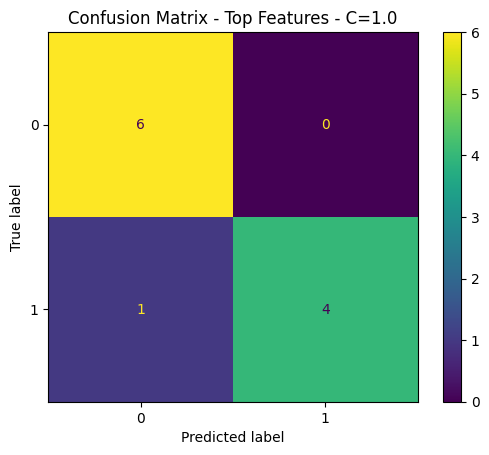

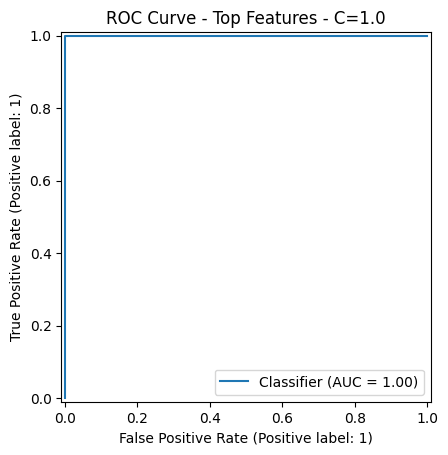


=== Logistic Regression | Top Features | C=0.1 | penalty=l2 ===
Accuracy: 0.9091
F1 Score: 0.8889
ROC AUC: 1.0


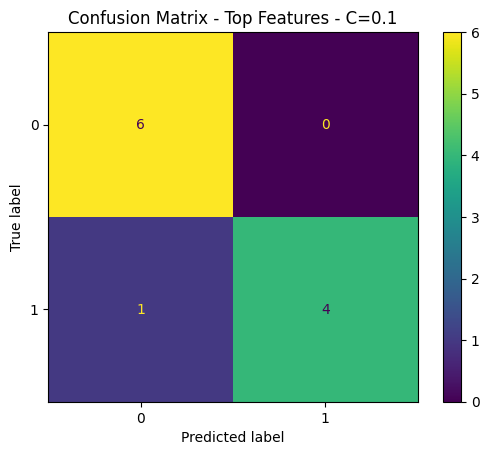

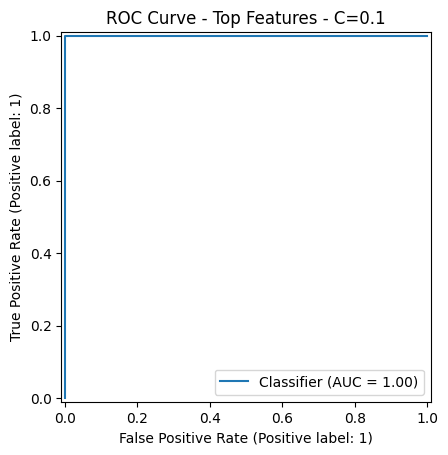


=== Logistic Regression | Top Features | C=0.01 | penalty=l2 ===
Accuracy: 1.0
F1 Score: 1.0
ROC AUC: 1.0


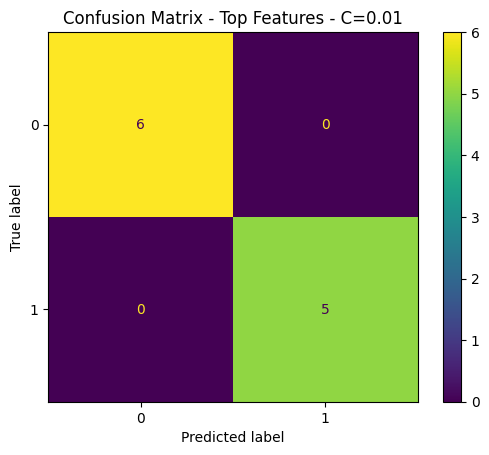

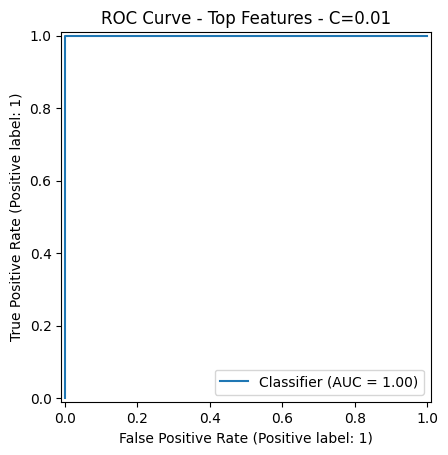

In [4]:
results = []

results.append(
    evaluate_logistic_model(
        X_top, y,
        feature_name="Top Features",
        C_value=1.0,
        penalty="l2",
        solver="liblinear"
    )
)

results.append(
    evaluate_logistic_model(
        X_top, y,
        feature_name="Top Features",
        C_value=0.1,
        penalty="l2",
        solver="liblinear"
    )
)

results.append(
    evaluate_logistic_model(
        X_top, y,
        feature_name="Top Features",
        C_value=0.01,
        penalty="l2",
        solver="liblinear"
    )
)


=== Logistic Regression | PCA 20 | C=1.0 | penalty=l2 ===
Accuracy: 0.6364
F1 Score: 0.6
ROC AUC: 0.4833


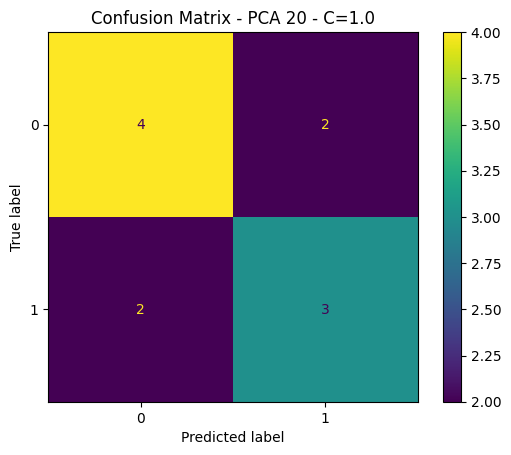

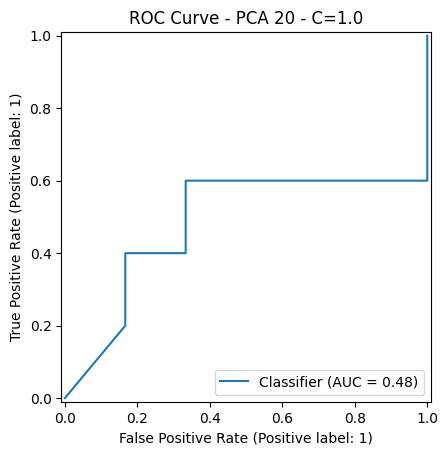


=== Logistic Regression | PCA 20 | C=0.1 | penalty=l2 ===
Accuracy: 0.6364
F1 Score: 0.6
ROC AUC: 0.5


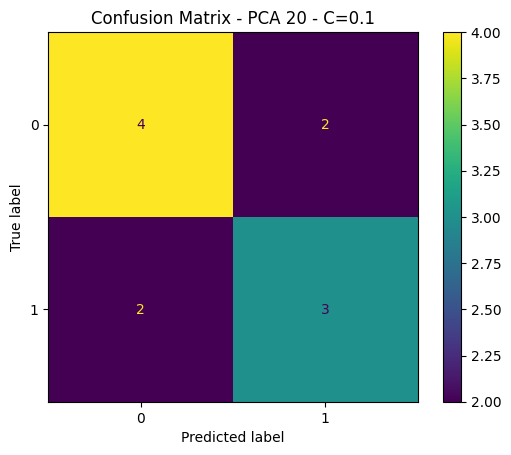

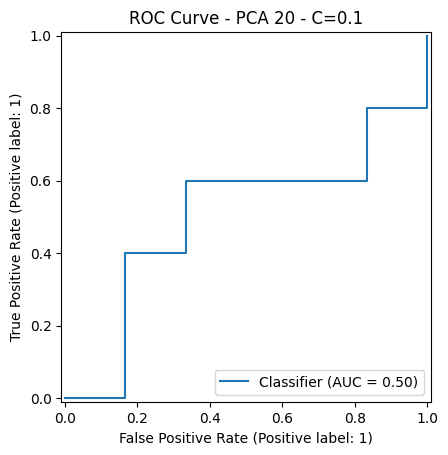


=== Logistic Regression | PCA 20 | C=0.01 | penalty=l2 ===
Accuracy: 0.5455
F1 Score: 0.6154
ROC AUC: 0.7


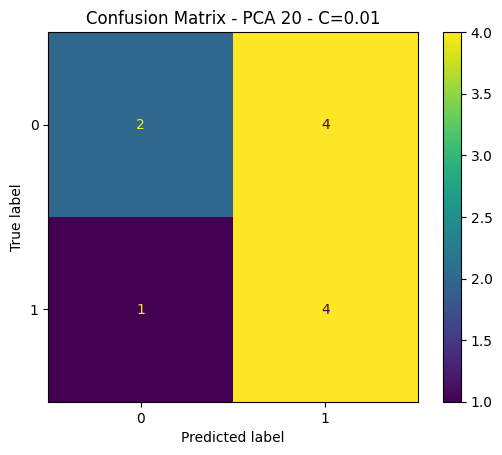

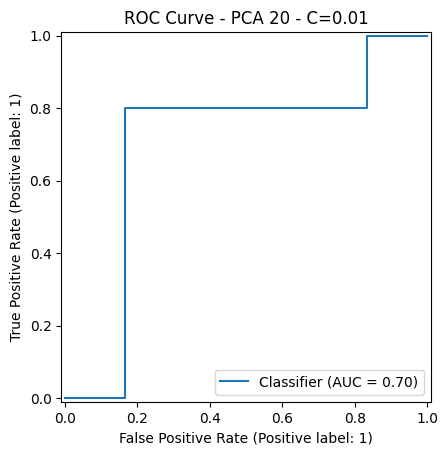

In [5]:
results.append(
    evaluate_logistic_model(
        X_pca_20, y,
        feature_name="PCA 20",
        C_value=1.0,
        penalty="l2",
        solver="liblinear"
    )
)

results.append(
    evaluate_logistic_model(
        X_pca_20, y,
        feature_name="PCA 20",
        C_value=0.1,
        penalty="l2",
        solver="liblinear"
    )
)

results.append(
    evaluate_logistic_model(
        X_pca_20, y,
        feature_name="PCA 20",
        C_value=0.01,
        penalty="l2",
        solver="liblinear"
    )
)


=== Logistic Regression | Top Features | C=0.1 | penalty=l1 ===
Accuracy: 0.5455
F1 Score: 0.0
ROC AUC: 0.5


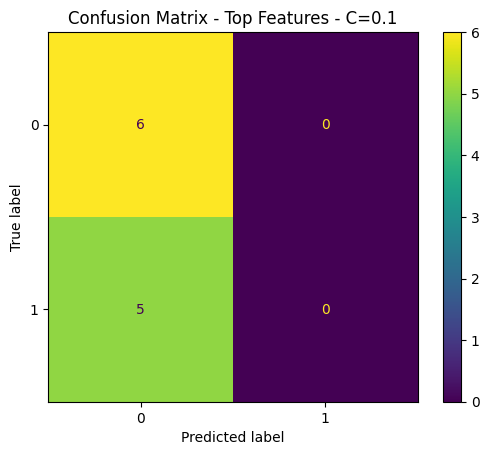

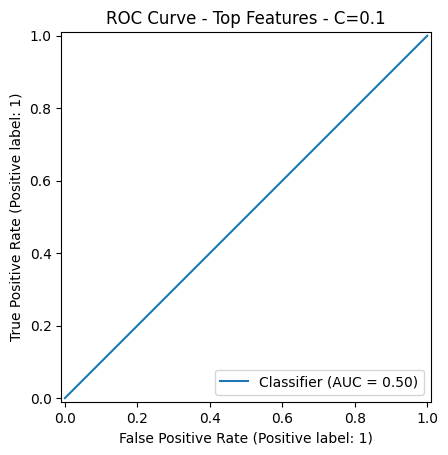

In [6]:
results.append(
    evaluate_logistic_model(
        X_top, y,
        feature_name="Top Features",
        C_value=0.1,
        penalty="l1",
        solver="liblinear"
    )
)

In [7]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)
results_df

,Feature_Set,C,Penalty,Accuracy,F1,ROC_AUC
0,Top Features,1.00,l2,0.909091,0.888889,1.000000
1,Top Features,0.10,l2,0.909091,0.888889,1.000000
2,Top Features,0.01,l2,1.000000,1.000000,1.000000
3,PCA 20,0.01,l2,0.545455,0.615385,0.700000
4,Top Features,0.10,l1,0.545455,0.000000,0.500000
5,PCA 20,0.10,l2,0.636364,0.600000,0.500000
6,PCA 20,1.00,l2,0.636364,0.600000,0.483333


In [8]:
def cross_validate_logistic(X, y, feature_name, C_value=0.1, penalty="l2", solver="liblinear"):
    model = LogisticRegression(
        max_iter=2000,
        C=C_value,
        penalty=penalty,
        solver=solver,
        random_state=42
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    auc_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring="f1")
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

    print(f"\n=== Cross-Validation | {feature_name} | C={C_value} | penalty={penalty} ===")
    print("Mean Accuracy:", round(acc_scores.mean(), 4))
    print("Mean F1:", round(f1_scores.mean(), 4))
    print("Mean ROC AUC:", round(auc_scores.mean(), 4))

    return {
        "Feature_Set": feature_name,
        "C": C_value,
        "Penalty": penalty,
        "CV_Accuracy": acc_scores.mean(),
        "CV_F1": f1_scores.mean(),
        "CV_ROC_AUC": auc_scores.mean()
    }

In [9]:
cv_results = []

cv_results.append(
    cross_validate_logistic(
        X_top, y,
        feature_name="Top Features",
        C_value=0.1,
        penalty="l2",
        solver="liblinear"
    )
)

cv_results.append(
    cross_validate_logistic(
        X_pca_20, y,
        feature_name="PCA 20",
        C_value=0.1,
        penalty="l2",
        solver="liblinear"
    )
)

cv_results.append(
    cross_validate_logistic(
        X_top, y,
        feature_name="Top Features",
        C_value=0.1,
        penalty="l1",
        solver="liblinear"
    )
)


=== Cross-Validation | Top Features | C=0.1 | penalty=l2 ===
Mean Accuracy: 0.6673
Mean F1: 0.6356
Mean ROC AUC: 0.7347

=== Cross-Validation | PCA 20 | C=0.1 | penalty=l2 ===
Mean Accuracy: 0.5855
Mean F1: 0.5834
Mean ROC AUC: 0.5867

=== Cross-Validation | Top Features | C=0.1 | penalty=l1 ===
Mean Accuracy: 0.5709
Mean F1: 0.4737
Mean ROC AUC: 0.632


In [ ]:
cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values(by="CV_ROC_AUC", ascending=False).reset_index(drop=True)
cv_results_df 

,Feature_Set,C,Penalty,CV_Accuracy,CV_F1,CV_ROC_AUC
0,Top Features,0.1,l2,0.667273,0.635556,0.734667
1,Top Features,0.1,l1,0.570909,0.473651,0.632000
2,PCA 20,0.1,l2,0.585455,0.583419,0.586667
